In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from torch.optim import AdamW
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

In [2]:
root_path = "/home/stefan/ioai-prep/kits/textual_similarity_oracle"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Data

In [3]:
df_test = pd.read_csv(f"{root_path}/test.csv")
df_train = pd.read_csv(f"{root_path}/train.csv")

df_train.head()

,sampleID,sentence1,sentence2,score
0,0,A plane is taking off.,An air plane is taking off.,5.00
1,1,A man is playing a large flute.,A man is playing a flute.,3.80
2,2,A man is spreading shreded cheese on a pizza.,A man is spreading shredded cheese on an uncoo...,3.80
3,3,Three men are playing chess.,Two men are playing chess.,2.60
4,4,A man is playing the cello.,A man seated is playing the cello.,4.25


# Subtask 1

In [4]:
def get_length_label(row):
    len1 = len(row["sentence1"])
    len2 = len(row["sentence2"])

    avg_len = (len1 + len2) / 2
    # subtask broken btw
    if avg_len < 50:
        return "Short"
    return "Long"


subtask1 = df_test.apply(get_length_label, axis=1)
subtask1.head()

0    Short
1    Short
2    Short
3    Short
4    Short
dtype: object

# Subtask 2

In [5]:
# tok = lambda u: [
#     t
#     for t in re.split(r"[ ]+", u)
#     if (t not in ".!?'\"-$:") or (not any(ch.isdigit() for ch in t))
# ]

In [6]:
subtask2 = df_test.apply(
    lambda r: len(r["sentence1"].split()) + len(r["sentence2"].split()), axis=1
)
subtask2.head()

0    12
1    19
2    13
3    13
4    12
dtype: int64

<Axes: >

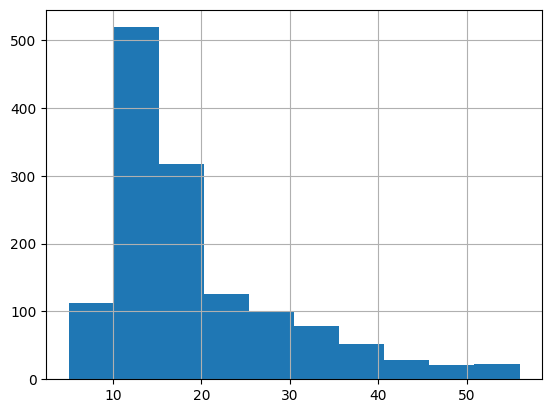

In [7]:
subtask2.hist()

# Subtask 3

In [8]:
subtask3 = df_test.apply(
    lambda r: abs(len(r["sentence1"]) - len(r["sentence2"])), axis=1
)
subtask3.head()

0    1
1    8
2    6
3    3
4    4
dtype: int64

# Subtask 4

In [9]:
model_name = "cross-encoder/stsb-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=1, ignore_mismatched_sizes=True
).to(device)

## Data

In [10]:
class STSDataset(Dataset):
    def __init__(self, df, tokenizer, is_test=False):
        self.df = df
        self.tokenizer = tokenizer
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        s1 = str(row["sentence1"])
        s2 = str(row["sentence2"])

        # Cross-encoder input: [CLS] s1 [SEP] s2 [SEP]
        encoding = self.tokenizer(
            s1,
            s2,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=128,
        )

        item = {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
        }

        if not self.is_test:
            # Normalize score if needed, but here we predict raw 0-5
            item["labels"] = torch.tensor(float(row["score"]), dtype=torch.float)

        return item

In [11]:
BATCH_SIZE = 32

train_dataset = STSDataset(df_train, tokenizer)
test_dataset = STSDataset(df_test, tokenizer, is_test=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Training

In [12]:
EPOCHS = 4
LR = 2e-5

In [13]:
optimizer = AdamW(model.parameters(), lr=LR)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=0, num_training_steps=total_steps
)

criterion = nn.L1Loss()

In [14]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch in tqdm(loader, desc="Training"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        model.zero_grad()

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits.squeeze(-1)

        loss = criterion(logits, labels)
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    return total_loss / len(loader)

In [15]:
for epoch in range(EPOCHS):
    avg_loss = train_epoch(model, train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train MAE: {avg_loss:.4f}")

Training: 100%|██████████| 180/180 [00:32<00:00,  5.50it/s]


Epoch 1/4 | Train MAE: 0.3165


Training: 100%|██████████| 180/180 [00:32<00:00,  5.55it/s]


Epoch 2/4 | Train MAE: 0.2221


Training: 100%|██████████| 180/180 [00:32<00:00,  5.50it/s]


Epoch 3/4 | Train MAE: 0.2028


Training: 100%|██████████| 180/180 [00:32<00:00,  5.48it/s]

Epoch 4/4 | Train MAE: 0.1842


## Inference

In [16]:
def predict(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Predicting"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits.squeeze(-1)
            preds.extend(logits.cpu().numpy())
    return np.array(preds)


raw_preds = predict(model, test_loader)

# Clip predictions to valid range [0, 5]
subtask4 = np.clip(raw_preds, 0, 5)
print(f"Predictions mean: {subtask4.mean()}")

Predicting: 100%|██████████| 44/44 [00:02<00:00, 15.62it/s]

Predictions mean: 2.7773590087890625


# Submission

In [17]:
subtasks = [
    (1, subtask1),
    (2, subtask2),
    (3, subtask3),
    (4, subtask4),
]

In [18]:
def build_subtask(sid, answer):
    return pd.DataFrame({
        "subtaskID": sid,
        "datapointID": df_test["sampleID"],
        "answer": answer
    })

submission = pd.concat([build_subtask(sid, ans) for sid, ans in subtasks])
submission.head()

,subtaskID,datapointID,answer
0,1,5749,Short
1,1,5750,Short
2,1,5751,Short
3,1,5752,Short
4,1,5753,Short


In [19]:
submission.to_csv(f"{root_path}/submission.csv", index=False)